In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import datetime 

I0000 00:00:1785480525.408464    1983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785480525.443502    1983 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785480527.389829    1983 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785480531.302796    1983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them 

# 1. Load Fashion-MNIST

Label: 9 = Ankle boot


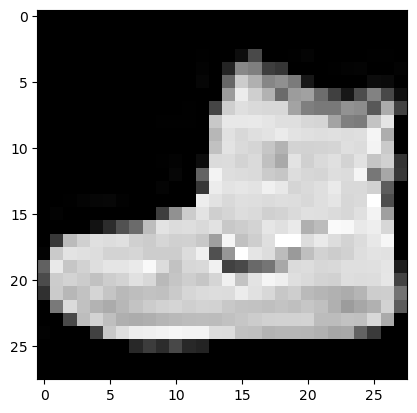

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixels (0-255 → 0-1)
X_train = X_train/250.0
X_test = X_test/250.0

# Flatten images (28x28 → 784)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Label: {y_train[0]} = {class_names[y_train[0]]}")
plt.imshow(X_train[0], cmap='gray')
plt.show()

# 2. Build Simple Classifier

In [4]:
model_linear = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(10, activation='softmax', input_shape=(784,))
])

model_linear.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_linear.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

/opt/conda/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1785480565.517812    1983 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8006 - loss: 0.5836 - val_accuracy: 0.8292 - val_loss: 0.5063
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8419 - loss: 0.4654 - val_accuracy: 0.8352 - val_loss: 0.4836
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8494 - loss: 0.4443 - val_accuracy: 0.8367 - val_loss: 0.4964
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8535 - loss: 0.4336 - val_accuracy: 0.8420 - val_loss: 0.4645
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8553 - loss: 0.4269 - val_accuracy: 0.8404 - val_loss: 0.4621


# 3. Build Deep Neural Network

In [11]:
model_deep = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_deep.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy']
                  )

history = model_deep.fit(X_train_flat,y_train, epochs=10,
                        validation_data=(X_test_flat,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7939 - loss: 0.5733 - val_accuracy: 0.8488 - val_loss: 0.4224
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8454 - loss: 0.4262 - val_accuracy: 0.8516 - val_loss: 0.4028
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8590 - loss: 0.3922 - val_accuracy: 0.8556 - val_loss: 0.3971
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8653 - loss: 0.3702 - val_accuracy: 0.8715 - val_loss: 0.3607
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8703 - loss: 0.3523 - val_accuracy: 0.8725 - val_loss: 0.3543
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8739 - loss: 0.3419 - val_accuracy: 0.8637 - val_loss: 0.3730
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8814 - loss: 0.3264 - val_accuracy: 0.8709 - val_loss: 0.3498
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8836 - loss: 0.3186 - 

# 4. TensorBoard Logging

In [ ]:
log_dir = "/home/jovyan/work/logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)